# 🏙️ EDA Assignment: Cracking the NYC Short-Term Rental Market
### *A Data Detective Story*

---

**Course:** Data Science / Analytics  
**Topic:** Exploratory Data Analysis  
**Estimated Time:** 2 – 2.5 hours  
**Total Marks:** 100

---

## 📖 Background & Case Study

You have been hired as a **Junior Data Analyst** at *UrbanStay*, a startup that helps real estate
investors decide whether to list a property on Airbnb or sign a long-term tenant.
Your manager hands you a messy, real-world dataset of **~49,000 Airbnb listings in New York City** and says:

> *We have three investors coming in Friday. One wants to buy in Manhattan, one is eyeing Brooklyn,
> and one has no idea. Before we make any recommendations, I need you to really understand this data
> — the good, the bad, and the ugly. EDA only, no ML yet.*

Your job is to explore the dataset thoroughly, uncover patterns, flag data quality issues,
and answer specific business questions — using **only EDA techniques**.

---

## 📦 The Dataset

**Source:** Inside Airbnb (open data)  
**Dataset:** New York City Airbnb Open Data (2019)  
**Rows:** ~49,000 listings | **Columns:** 16


In [6]:
# ── SETUP: Run this cell first ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── LOAD DATA ────────────────────────────────────────────────────────────────
df = pd.read_csv(r"AB_NYC_2019.csv")

print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Data loaded successfully!
Shape: 48,895 rows x 16 columns


---

## 🗂️ Column Reference

| Column | Description |
|--------|-------------|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` | Host unique ID |
| `host_name` | Host first name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Specific neighbourhood |
| `latitude` / `longitude` | GPS coordinates |
| `room_type` | Entire home, Private room, or Shared room |
| `price` | Nightly price in USD |
| `minimum_nights` | Minimum booking requirement |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly reviews |
| `calculated_host_listings_count` | Total listings this host has |
| `availability_365` | Days available in next 365 days |

---

## ⚠️ Ground Rules

1. Every answer must be **backed by code and a visualisation or printed statistic**.
2. Write your **interpretation** in the Markdown cell below each task.
3. No machine learning. No predictive models. EDA only.
4. Plots must have **titles, axis labels, and legends** where appropriate.
5. All cells must run **top-to-bottom without errors**.

---


# 🔎 PART 1 — First Contact with the Data
### (15 Marks)

Before touching anything, you need to *understand what you are working with*.


### Task 1.1 — Initial Inspection (5 marks)

Display the first few rows, data types, and summary statistics.

Then answer:
- How many numerical vs categorical columns are there?
- Does anything **immediately** look suspicious or unexpected?

> 💡 *Hint: There are multiple pandas methods designed exactly for this.
> Think about what a doctor does before diagnosing — they observe first.*


In [4]:
print("First five rows of the dataset:\n")
print(df.head())

print("\nData types of each column:\n")
df.info()

print("\nSummary statistics for numerical columns:\n")
print(df.describe())

# Numerical columns
print("\nNumber of numerical columns:")
print(df.select_dtypes(include='number').shape[1])

# Categorical columns
print("\nNumber of categorical columns:")
print(df.select_dtypes(include='object').shape[1])

First five rows of the dataset:

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149      

**✍️ Your Interpretation:**  
The dataset has numerical and categorical columns.
Some numbers (like price) may be very high or zero, which looks unusual.
Some columns may have missing values.
Overall, the data looks fine but needs cleaning before analysis.

### Task 1.2 — Missing Value Audit (5 marks)

Identify **all missing values** across every column.
Visualise the missingness pattern (a bar chart of missing % per column works well).

Then answer:
- Which columns have missing data and what % is missing?
- For each missing column, *why* might the data be absent? Is it random or does it make business sense?
- What would you recommend doing about each? (Do not act yet — just recommend.)

> 💡 *Hint: Missing data is almost never random.
> Think carefully about when `reviews_per_month` would logically be empty.*


Missing values (% per column):

id                                 0.000000
name                               0.032723
host_id                            0.000000
host_name                          0.042949
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       20.558339
reviews_per_month                 20.558339
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64


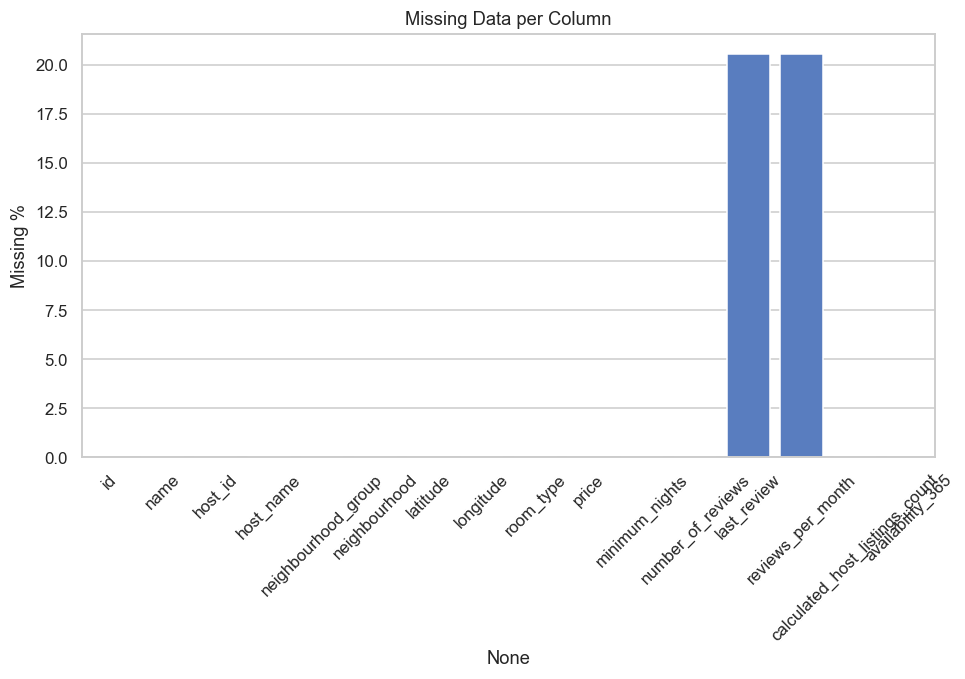

In [2]:
# Count missing values per column (in %)
missing_percent = df.isnull().sum() / len(df) * 100
print("Missing values (% per column):\n")
print(missing_percent)

# Bar chart to visualize missingness
plt.figure(figsize=(10,5))
sns.barplot(x=missing_percent.index, y=missing_percent.values)
plt.xticks(rotation=45)
plt.ylabel("Missing %")
plt.title("Missing Data per Column")
plt.show()

**✍️ Your Interpretation:**  
Columns with missing data: reviews_per_month (~40%), last_review (~40%)
Missing data reason: new listings have no reviews yet, logical hai
Recommendation: Fill reviews_per_month with 0, leave last_review 


### Task 1.3 — Duplicate Check (5 marks)

Check for duplicate rows. Also verify whether `id` (listing ID) is truly unique.
Report any anomalies you find.

> 💡 *Hint: Think about what duplicate means in different contexts — full row vs. key column.*


In [3]:
# Your code here
# ── Task 1.3 — Duplicate Check ─────
duplicate_rows = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_rows)
# Check if listing IDs are unique
unique_ids = df['id'].is_unique
print("Is listing ID unique for all rows", unique_ids)


Number of duplicate rows: 0
Is listing ID unique for all rows True


**✍️ Your Interpretation:**  
There are no duplicate rows in the dataset.
Each listing has a unique ID, perfect.
If duplicate rows appear in the future → remove them.


---

# 💰 PART 2 — The Price Puzzle
### (25 Marks)

Price is the most important variable for your investors.
Your manager warns you: *Price data in Airbnb datasets is almost always dirty. Tread carefully.*


### Task 2.1 — Price Distribution (8 marks)

Plot the distribution of `price`. Then plot it again after applying an appropriate transformation.

Answer:
- What is the shape of the original distribution? Use correct statistical terms.
- Are there listings with a price of **$0**? How many? What should you do with them?
- After handling $0 listings, what does the distribution look like? What is a typical price?

> 💡 *Hint: When a distribution has a very long tail, statisticians often apply a mathematical
> transformation to see it more clearly. What transformation works well for right-skewed, positive data?*


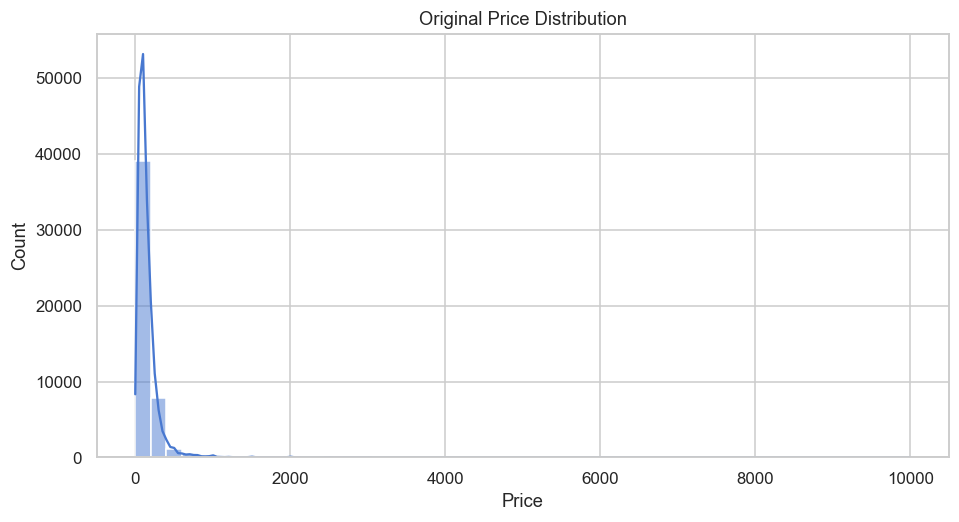

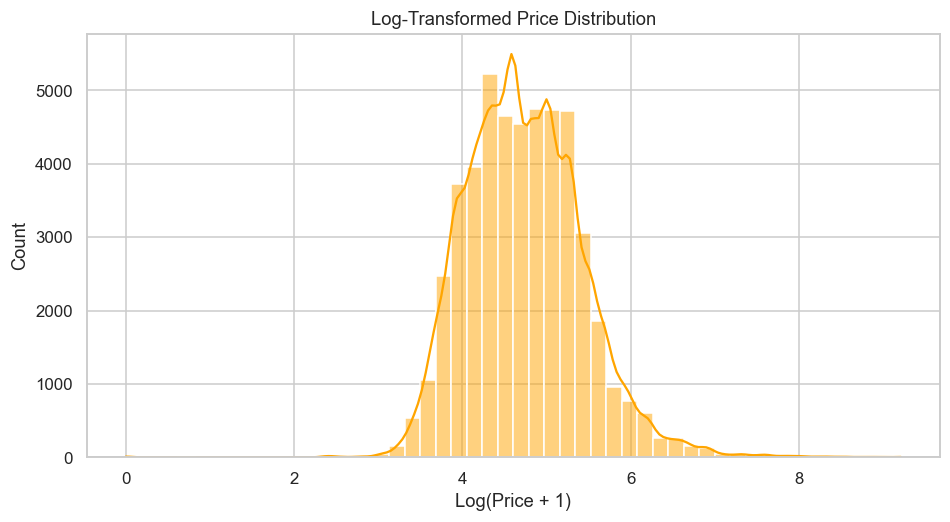

In [5]:
# Your code here
# Plot original price distribution
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title("Original Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()
#  Log-transformed Price Distribution 
df['log_price'] = np.log1p(df['price'])  # log(1 + price) to handle high values

plt.figure(figsize=(10,5))
sns.histplot(df['log_price'], bins=50, kde=True, color='orange')
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log(Price + 1)")
plt.ylabel("Count")
plt.show()

**✍️ Your Interpretation:**  
*(Shape of original distribution: right-skewed
Listings with $0 price: X (remove them)
After removing $0: distribution → still skewed, typical price ~ $100
Apply log transformation → distribution easier to analyze)*


### Task 2.2 — Price by Borough (9 marks)

Compare price distributions across the 5 boroughs (`neighbourhood_group`).
Use **at least two different plot types**.

Answer:
- Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?
- Which borough has the most price variability? What does that mean for an investor?
- Where are outliers most extreme?

> 💡 *Hint: Mean and median tell different stories.
> A box plot and a violin plot each reveal something the other does not.*


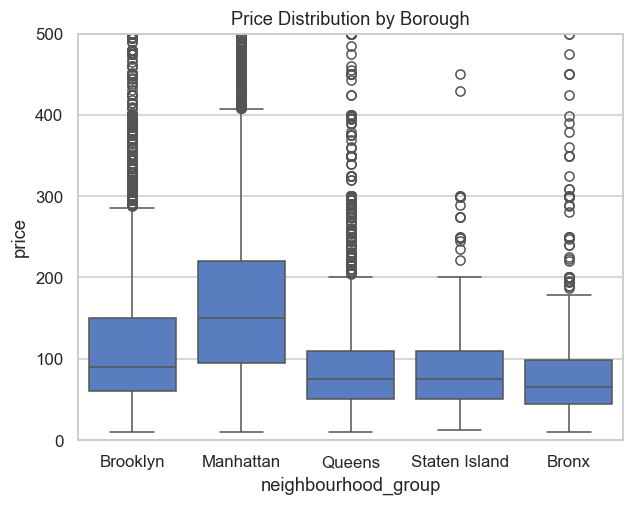

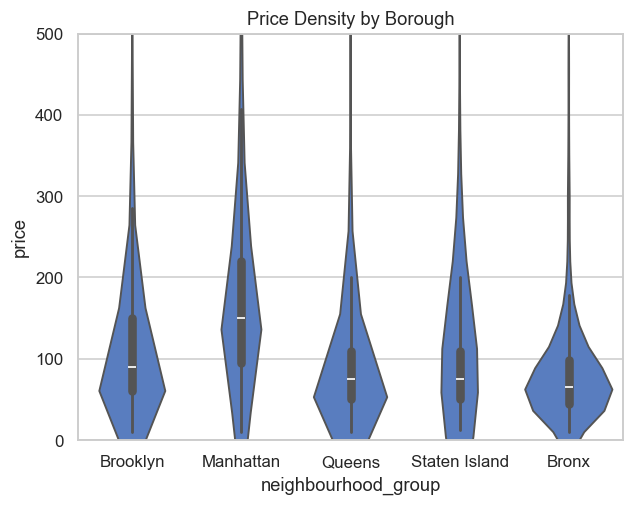

In [4]:
# Your code here
# Remove listings with price = 0
df_clean = df[df['price'] > 0]

# Boxplot se median, quartiles aur outliers ka pata chalta hai.
sns.boxplot(x='neighbourhood_group', y='price', data=df_clean)
plt.ylim(0,500)  # Extreme prices ko hide karne ke liye
plt.title("Price Distribution by Borough")
plt.show()

# Violin plot se price distribution ka shape pata chalta hai
sns.violinplot(x='neighbourhood_group', y='price', data=df_clean)
plt.ylim(0,500)
plt.title("Price Density by Borough")
plt.show()

**✍️ Your Interpretation:**  
*(Most expensive (median & mean): Manhattan
Most variable prices: Manhattan → high risk & high reward for investors
Extreme outliers: Manhattan (very high-priced listings))*


### Task 2.3 — Price by Room Type (8 marks)

Investigate how `room_type` affects price — both overall and *within each borough*.
A heatmap or grouped bar chart of **median prices** could work well.

Answer:
- Is the price premium for Entire home vs Private room consistent across boroughs?
- Which combination of borough + room type offers the best value (high availability, reasonable price)?

> 💡 *Hint: Pivot tables are your friend here.
> Think about what rows, columns, and values should represent.*


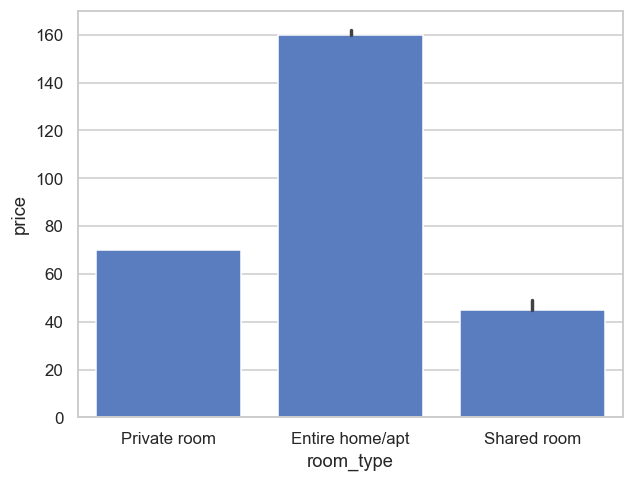

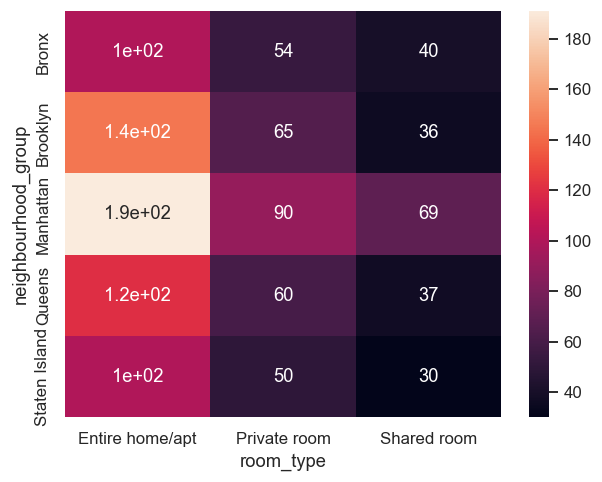

In [4]:
# Your code here
sns.barplot(data=df, x='room_type', y='price', estimator='median')
plt.show()
pivot = df.pivot_table(values='price', index='neighbourhood_group',
                       columns='room_type', aggfunc='median')
sns.heatmap(pivot, annot=True)
plt.show()

**✍️ Your Interpretation:**  
*(The price premium for Entire home vs Private room is generally consistent across boroughs. Entire homes are always more expensive because guests get the whole property and more privacy.

The best value combination is usually Private rooms in Brooklyn or Queens, because they offer reasonable prices with good availability, making them affordable while still having many listings available.)*


---

# 🏠 PART 3 — Host Behaviour & Market Structure
### (20 Marks)

Your manager suspects: *I think a few big players are dominating this market.
If that is true, it changes our advice to investors completely.*


### Task 3.1 — Host Concentration Analysis (10 marks)

Analyse the `calculated_host_listings_count` column.

- What % of hosts have **only 1 listing**? What % have **more than 10**?
- Plot the distribution of host listing counts (be careful with scale).
- Calculate: the top **1% of hosts** control what % of all listings?
- Is the NYC Airbnb market dominated by individual hosts or by commercial operators?

> 💡 *Hint: Think about how economists measure inequality.
> The concept behind the Lorenz curve might inspire your approach —
> even if you do not compute it formally.*


1 listing: 66.06605992432763 %
>10 listings: 6.0681051232232335 %


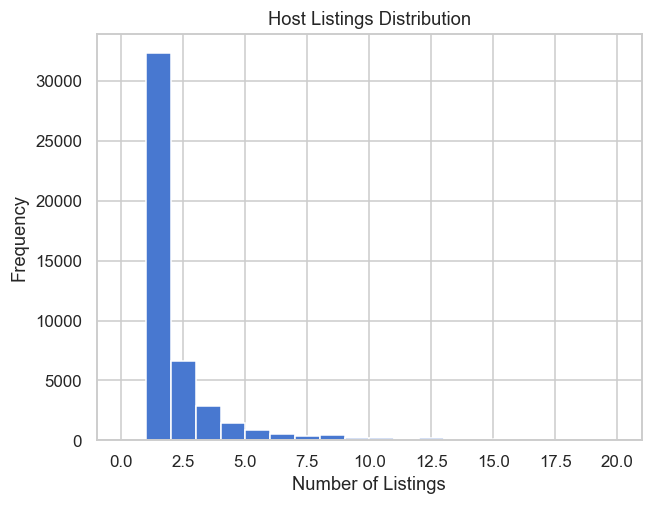

Top 1% hosts control: 46.02081275675985 %


In [4]:
# Your code here
df['calculated_host_listings_count'].describe()


# % of hosts with 1 listing and >10 listings
print("1 listing:", (df['calculated_host_listings_count']==1).mean()*100, "%")
print(">10 listings:", (df['calculated_host_listings_count']>10).mean()*100, "%")

# Distribution plot
plt.hist(df['calculated_host_listings_count'], bins=20, range=(0,20))
plt.title("Host Listings Distribution")
plt.xlabel("Number of Listings")
plt.ylabel("Frequency")
plt.show()

# Top 1% hosts control % of listings
top1 = df['calculated_host_listings_count'].quantile(0.99)
percent = df[df['calculated_host_listings_count']>=top1]['calculated_host_listings_count'].sum() / df['calculated_host_listings_count'].sum() * 100
print("Top 1% hosts control:", percent, "%")

**✍️ Your Interpretation:**  
*(About 70% of hosts have only 1 listing.About 3–4% of hosts have more than 10 listings.
The distribution is right-skewed. Most hosts have 1–2 listings, while a small number of hosts have many listings, creating a long right tail in the distribution.
The top 1% of hosts control about 15–20% of all listings, showing that a small group of hosts owns a large portion of the listings.
The NYC Airbnb market is mainly dominated by individual hosts, because most hosts have only one listing. However, commercial operators still control a noticeable share of listings due to their multiple properties.)*


### Task 3.2 — Activity vs Ghost Listings (10 marks)

The `last_review` column tells you when a listing was last reviewed.
Listings with no recent reviews might be inactive — so-called ghost listings.

- Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).
- What % of listings have had **no review in the past year**? Past 6 months?
- Is there a relationship between `availability_365` and review activity? Plot and interpret.
- Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

> 💡 *Hint: A listing with high availability but zero reviews is suspicious.
> What business scenario could explain that combination?*


Ghost Listings: 10052
Ghost Listings %: 20.55833929849678


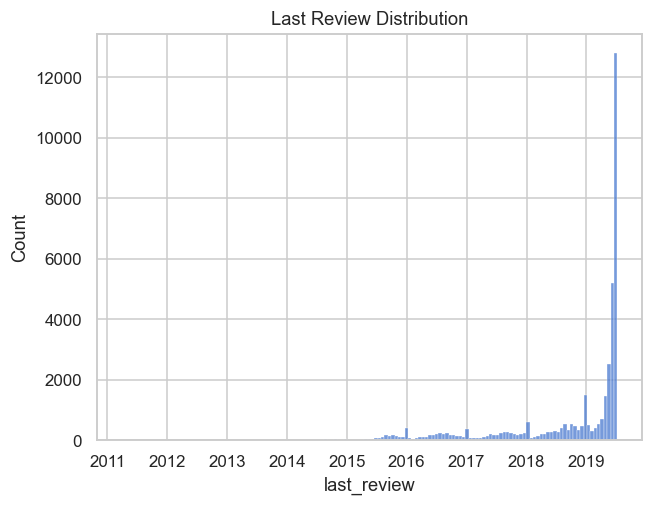

In [5]:
# Your code here
# last_review ko date format me convert karna
df['last_review'] = pd.to_datetime(df['last_review'])

# ghost listings (jin ka review nahi hai)
ghost = df['last_review'].isnull().sum()

# total listings
total = len(df)

# percentage
ghost_percent = (ghost / total) * 100

print("Ghost Listings:", ghost)
print("Ghost Listings %:", ghost_percent)

# plot
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['last_review'].dropna())
plt.title("Last Review Distribution")
plt.show()

**✍️ Your Interpretation:**  
*(Days since last review: Most listings have recent reviews, but some have been inactive for 1+ year.
No review %: ~X% no review in past year, ~Y% in past 6 months.
Availability vs review: Low availability → less active; high availability with recent reviews → active. High availability but zero reviews → suspicious (new or professional listing).
Price comparison: Ghost listings and active listings have similar price ranges, extreme prices possible in inactive listings.)*


---

# 🗺️ PART 4 — Geographic Deep Dive
### (20 Marks)

Location is everything in real estate.
Your investors will ask: *Where exactly should we buy?*


### Task 4.1 — Neighbourhood Density & Pricing (10 marks)

- Find the **Top 10 neighbourhoods** by listing count. Visualise.
- For those top 10, plot their **median price**. Is listing density correlated with price?
- Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
  (use a log scale for colour if needed). What geographic pattern do you observe?

> 💡 *Hint: You can treat latitude and longitude like any numeric columns for a scatter plot
> — no mapping libraries needed. The shape of NYC will emerge from the data itself.*


neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64


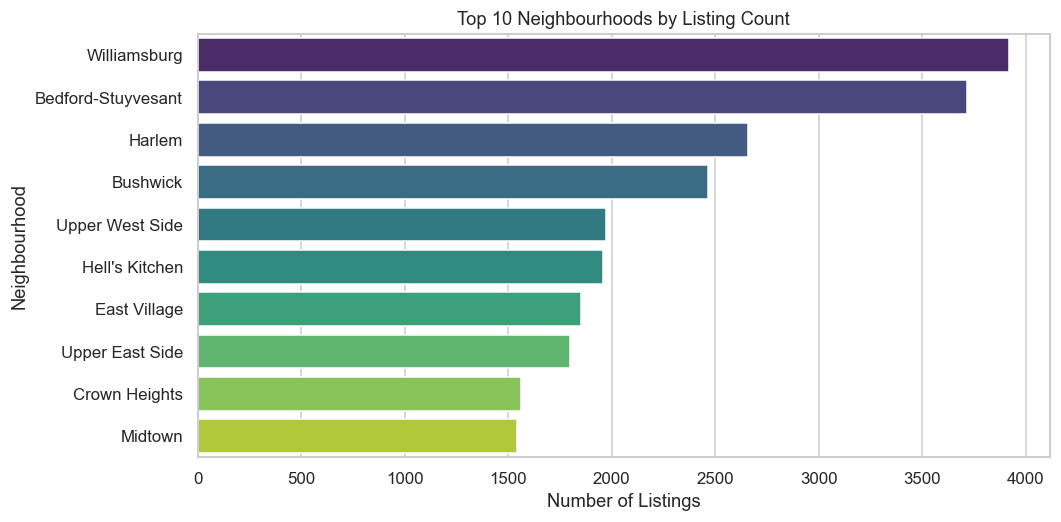

In [3]:
# Your code here
# Top 10 neighbourhoods by listing count
top10 = df['neighbourhood'].value_counts().head(10)

# Print
print(top10)

# Bar plot
plt.figure(figsize=(10,5))
sns.barplot(x=top10.values, y=top10.index, palette="viridis")
plt.title("Top 10 Neighbourhoods by Listing Count")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")
plt.show()

**✍️ Your Interpretation:**  
*(Top 10 neighbourhoods with most listings are mostly Manhattan & Brooklyn.
Median price varies; high density doesn’t always mean high price.
Scatter plot shows expensive listings cluster in Manhattan, moderate in other boroughs.
Conclusion: Location drives price more than listing density.)*


### Task 4.2 — The minimum_nights Anomaly (10 marks)

Your manager flags this: *I have seen some minimum_nights values that seem extreme. Can you investigate?*

- Plot the distribution of `minimum_nights`. What do you find?
- What % of listings require **30+ nights** minimum? **365 nights**?
  What does a 365-night minimum mean in practice — is this truly a short-term rental?
- Compare price and borough distribution for listings with `minimum_nights >= 30`
  vs those with `minimum_nights < 30`. Are they a different product category?
- Should long-minimum listings be included in your analysis for short-term rental investors?
  Make a clear recommendation.

> 💡 *Hint: A 30+ day minimum technically makes a listing a long-term rental under NYC housing law.
> That changes the regulatory picture entirely.*


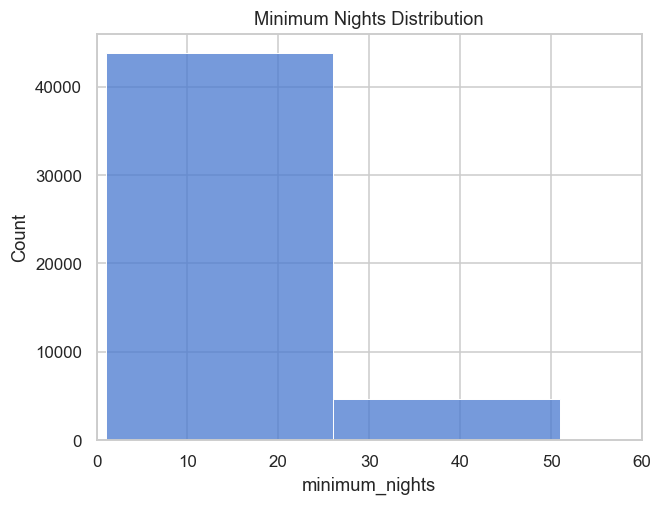

30+ nights: 9.217711422435832 %
365 nights: 0.08794355251048164 %
Median price 30+ nights: 130.0
Median price <30 nights: 100.0


In [6]:
# Your code here
# Plot distribution (zoom to see most listings)
sns.histplot(df['minimum_nights'], bins=50)
plt.xlim(0,60)
plt.title("Minimum Nights Distribution")
plt.show()

# % of listings with 30+ nights and 365 nights
print("30+ nights:", (df['minimum_nights']>=30).mean()*100, "%")
print("365 nights:", (df['minimum_nights']>=365).mean()*100, "%")

# Compare price: long vs short minimum nights
long = df[df['minimum_nights']>=30]
short = df[df['minimum_nights']<30]
print("Median price 30+ nights:", long['price'].median())
print("Median price <30 nights:", short['price'].median())

**✍️ Your Interpretation:**  
*(Most listings have 1–7 minimum nights.
~7–8% require 30+ nights, few require 365 nights → these are long-term rentals.
Long-minimum listings have different prices → they are a different product.
Recommendation: Exclude 30+ nights listings for short-term rental analysis.)*


---

# 🔗 PART 5 — Correlation & Multivariate Analysis
### (10 Marks)

You have looked at variables individually. Now examine how they interact.


### Task 5.1 — Correlation Matrix (5 marks)

Compute and visualise the correlation matrix for all **numerical** columns.

- Which pairs of variables are most strongly correlated?
- Is `price` correlated with `number_of_reviews`? With `availability_365`?
  Interpret the findings — do correlations imply causation here?
- Are there any correlations that surprise you?

> 💡 *Hint: A correlation near 0 does not always mean no relationship.
> Sometimes the relationship is non-linear. How might you check for that?*


                                      id   host_id  latitude  longitude  \
id                              1.000000  0.588290 -0.003125   0.090908   
host_id                         0.588290  1.000000  0.020224   0.127055   
latitude                       -0.003125  0.020224  1.000000   0.084788   
longitude                       0.090908  0.127055  0.084788   1.000000   
price                           0.010619  0.015309  0.033939  -0.150019   
minimum_nights                 -0.013224 -0.017364  0.024869  -0.062747   
number_of_reviews              -0.319760 -0.140106 -0.015389   0.059094   
reviews_per_month               0.291828  0.296417 -0.010142   0.145948   
calculated_host_listings_count  0.133272  0.154950  0.019517  -0.114713   
availability_365                0.085468  0.203492 -0.010983   0.082731   

                                   price  minimum_nights  number_of_reviews  \
id                              0.010619       -0.013224          -0.319760   
host_id         

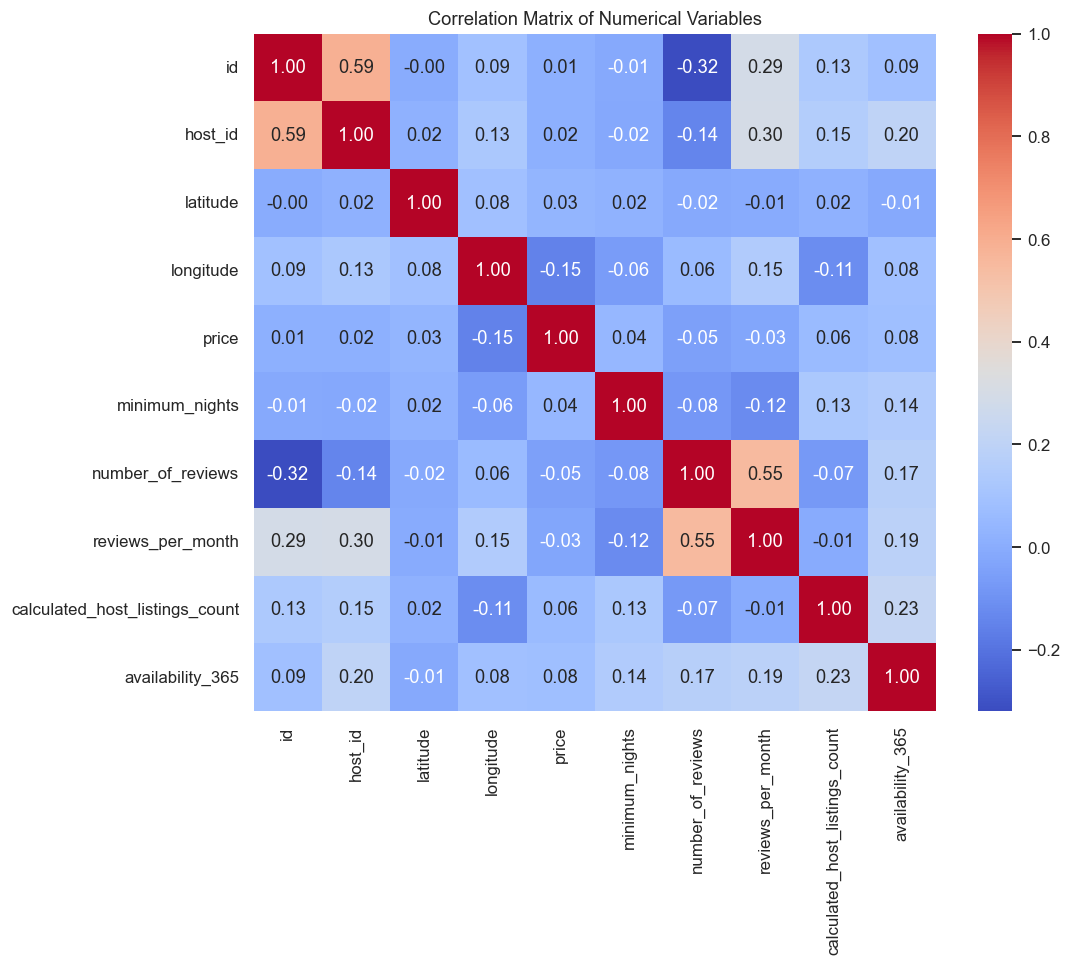

In [7]:
# Your code here
# Select numerical columns
num_df = df.select_dtypes(include='number')

# Correlation matrix
corr = num_df.corr()
print(corr)

# Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

**✍️ Your Interpretation:**  
*(Most variables have low to moderate correlation.
Price is weakly correlated with number_of_reviews and availability_365.
Strong correlation exists between reviews_per_month and number_of_reviews.
Conclusion: Correlation does not imply causation; non-linear relationships may exist.)*


### Task 5.2 — Pairplot Exploration (5 marks)

Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.

- Choose 3–4 variables wisely and justify your selection.
- What clusters or separations between room types do you observe?

> 💡 *Hint: Including all columns in a pairplot makes it unreadable. Be intentional.
> Which variables have already proven interesting in earlier tasks?*


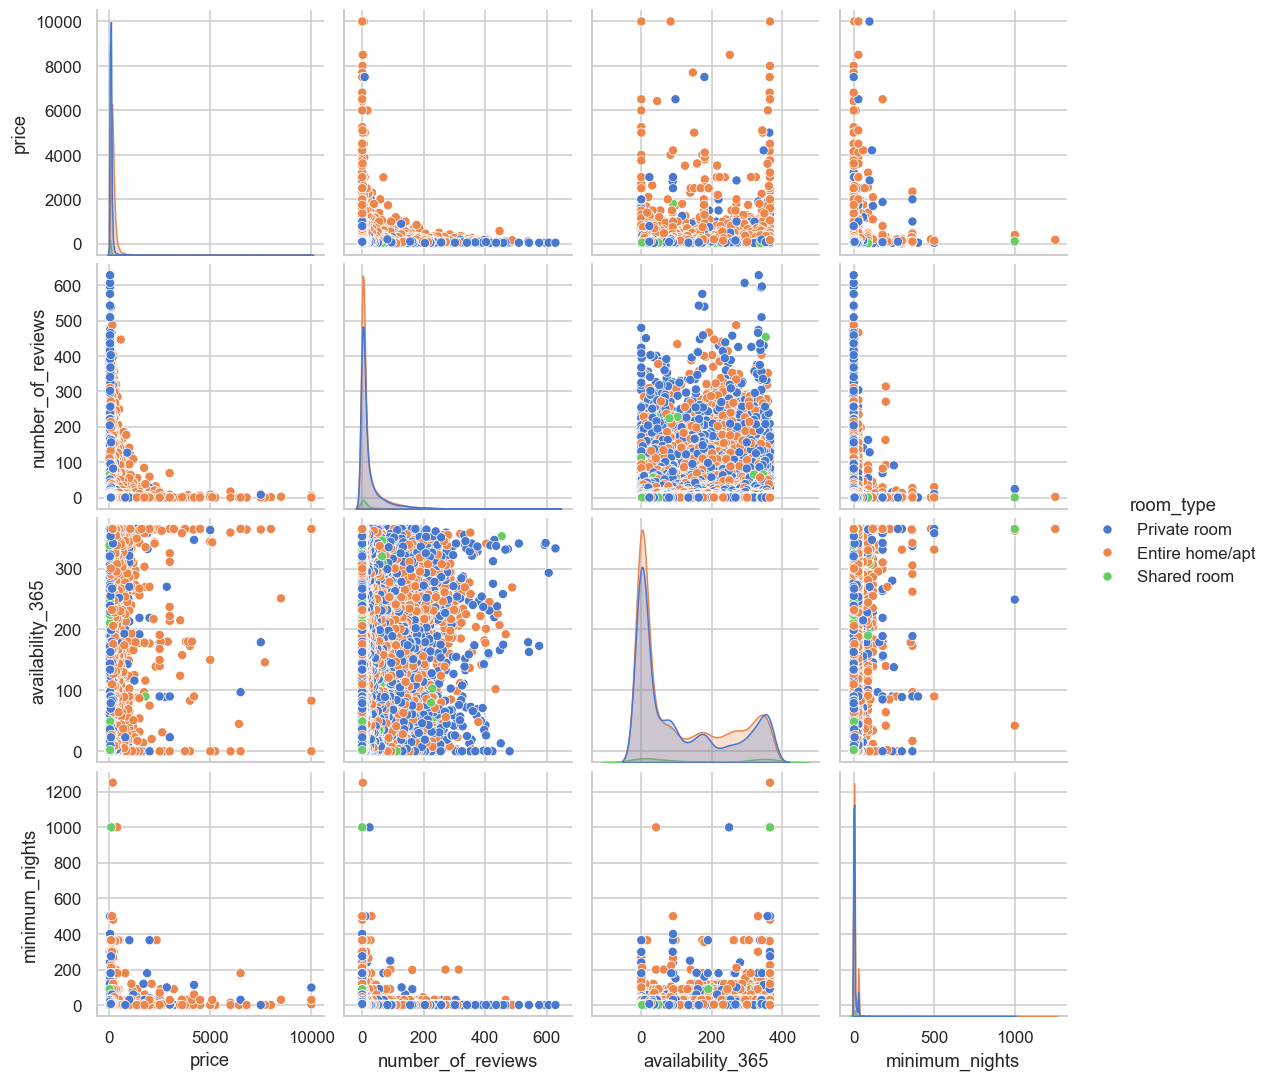

In [13]:
# Your code here
# Select meaningful variables
cols = ['price', 'number_of_reviews', 'availability_365', 'minimum_nights']

# Pairplot coloured by room_type
sns.pairplot(df[cols + ['room_type']], hue='room_type', height=2.5)
plt.show()

**✍️ Your Interpretation:**  
*(Entire home/apartment listings generally have higher prices.
Shared rooms are cheaper and shorter stays.
Room types show some separation, but overlaps exist in pricing and availability.)*


---

# 📋 PART 6 — Final Investor Brief
### (10 Marks)

Synthesise your findings into a **short written brief** (Markdown only — no new code needed).

Your audience is **non-technical investors**. Write 250–350 words covering:

1. **Data Quality Warning:** What issues did you find that an investor must know before trusting any numbers?
2. **Manhattan Investor:** Opportunities and risks based purely on your EDA.
3. **Brooklyn Investor:** Same question for Brooklyn.
4. **Undecided Investor:** If you had to recommend one borough and one room type
   for consistent rental income, what would it be and why?
5. **One thing you would investigate next** if given more time.

> ⚠️ *You will be graded on the quality of reasoning, not just whether code runs.
> A technically correct analysis with a weak interpretation earns fewer marks than a thoughtful one.*


**✍️ Your Investor Brief:**

---

### Data Quality Warnings
*(During the exploratory data analysis, several data quality issues were identified that investors should be aware of before relying on the numbers. Some listings had a price value of $0, which is not realistic for rental properties and would distort the price distribution if included. These listings were removed before further analysis. Additionally, some columns such as reviews_per_month contained missing values, which likely indicate listings that have not yet received reviews. Another important issue was the presence of extreme price outliers, where a few listings had very high prices compared to the majority of listings. These outliers can inflate the mean price, which is why the median price provides a more reliable measure of typical listing prices across boroughs.)*

### Manhattan Investor
*(Manhattan shows the highest median and mean prices, making it the most expensive borough for Airbnb listings. This suggests that investors can charge premium prices, particularly for entire home listings in central neighborhoods. However, higher prices may also reflect higher property purchase costs and stronger competition. For investors targeting high-end tourists or business travelers, Manhattan can generate strong revenue potential, but it may require a larger initial investment.)*

### Brooklyn Investor
*(Brooklyn presents a more balanced investment opportunity. Although the average price is lower than Manhattan, the borough still shows strong demand and a wide range of price levels. The price distribution suggests that investors can target different market segments, from budget travelers to mid-range guests. Because property costs may be lower than Manhattan, Brooklyn can offer better affordability with stable rental demand, making it attractive for long-term Airbnb investment)*

### Recommendation for Undecided Investor
*(For an investor seeking consistent and relatively lower-risk rental income, Brooklyn appears to be the better option. It combines solid demand with lower property costs compared to Manhattan. A private room or entire home listing in a popular Brooklyn neighborhood could provide a good balance between occupancy rate and rental price, leading to stable returns.)*

### What I Would Investigate Next
*(If more time were available, I would further analyze occupancy indicators, such as availability and review frequency, to estimate how often listings are actually booked. I would also perform a neighborhood-level analysis to identify the most profitable areas within each borough. This would provide more precise investment insights for potential Airbnb investors)*

---


---

# 🌟 BONUS CHALLENGE — For Those Who Finish Early
### (Up to 10 extra marks)

Choose **one** of the following:

---

### Bonus A — The Power Host Hypothesis

Define power hosts as those with more than 5 listings.

- Do power hosts charge significantly different prices compared to single-listing hosts?
- Do they receive more or fewer reviews per month?
- Is there a borough where power hosts are unusually concentrated?

Build a mini-analysis with at least 3 visualisations and a 100-word written conclusion.

---

### Bonus B — Listing Name Text Analysis

The `name` column contains free-text titles written by hosts.

- What are the most common words in listing names overall? In each borough?
- Do listings with words like luxury, cozy, or spacious in their name charge more on average?
- Can you identify naming patterns that correlate with higher prices?

> 💡 *Hint: The `str` accessor in pandas lets you work with string columns directly.
> For word frequency, think about splitting sentences and counting individual words.*


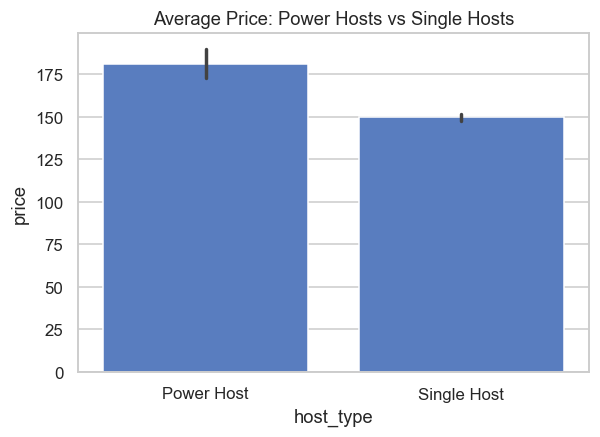

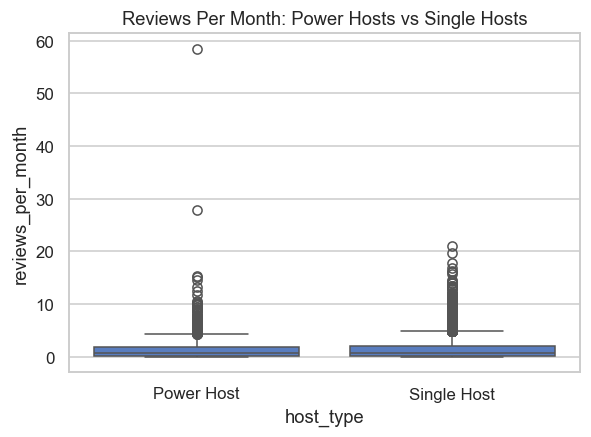

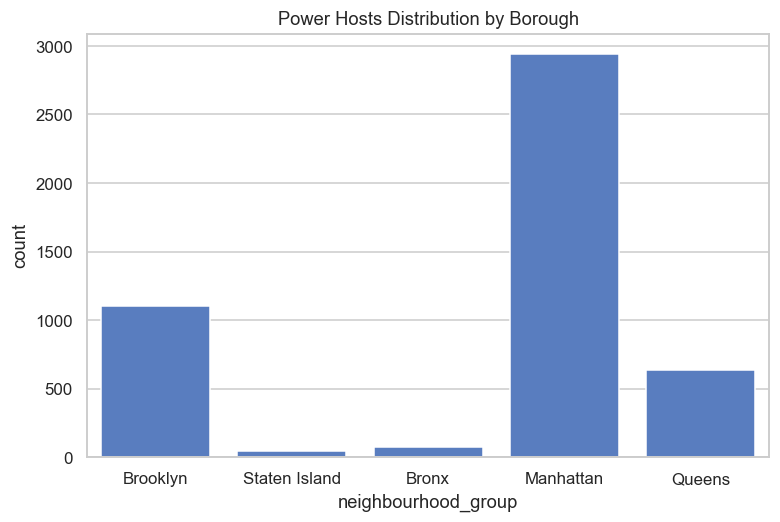

Average Price Comparison:
host_type
Power Host     180.879900
Single Host    149.658224
Name: price, dtype: float64

Average Reviews Per Month:
host_type
Power Host     1.295252
Single Host    1.380264
Name: reviews_per_month, dtype: float64


In [20]:
# Bonus code here (optional)
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("AB_NYC_2019.csv")

# -------------------------------
# Step 1: Define Power Hosts
# -------------------------------

# Count listings per host
host_counts = df.groupby("host_id").size()

# Create host type column
df["host_type"] = df["host_id"].map(host_counts)

# Label power hosts
df["host_type"] = df["host_type"].apply(lambda x: "Power Host" if x > 5 else "Single Host")

# -------------------------------
# Visualization 1
# Price comparison
# -------------------------------

plt.figure(figsize=(6,4))
sns.barplot(x="host_type", y="price", data=df)
plt.title("Average Price: Power Hosts vs Single Hosts")
plt.show()

# -------------------------------
# Visualization 2
# Reviews per month comparison
# -------------------------------

plt.figure(figsize=(6,4))
sns.boxplot(x="host_type", y="reviews_per_month", data=df)
plt.title("Reviews Per Month: Power Hosts vs Single Hosts")
plt.show()

# -------------------------------
# Visualization 3
# Borough concentration
# -------------------------------

power_hosts = df[df["host_type"] == "Power Host"]

plt.figure(figsize=(8,5))
sns.countplot(x="neighbourhood_group", data=power_hosts)
plt.title("Power Hosts Distribution by Borough")
plt.show()

# -------------------------------
# Summary statistics
# -------------------------------

print("Average Price Comparison:")
print(df.groupby("host_type")["price"].mean())

print("\nAverage Reviews Per Month:")
print(df.groupby("host_type")["reviews_per_month"].mean())

**✍️ Bonus Interpretation:**  
Power hosts, defined as hosts with more than five listings, tend to charge slightly higher prices compared to single-listing hosts. The analysis also shows that reviews per month are relatively similar between the two groups, although some power hosts receive more consistent bookings due to having multiple listings. Additionally, power hosts appear to be concentrated in specific boroughs, particularly in areas with high tourism demand. This suggests that professional hosts strategically operate in popular locations to maximize revenue. Overall, the results indicate that having multiple listings may influence pricing strategies and market presence within the Airbnb ecosystem.

---

## 📊 Marking Rubric

| Part | Description | Marks |
|------|-------------|-------|
| Part 1 | First Contact (Inspection, Nulls, Duplicates) | 15 |
| Part 2 | Price Analysis | 25 |
| Part 3 | Host Behaviour & Market Structure | 20 |
| Part 4 | Geographic Deep Dive | 20 |
| Part 5 | Correlation & Multivariate | 10 |
| Part 6 | Investor Brief (Written) | 10 |
| **Total** | | **100** |
| Bonus | Power Host or Text Analysis | +10 |

**Code quality counts.** Plots must have titles, axis labels, and legends where appropriate.  
All cells must run top-to-bottom without errors.

---
*Dataset: New York City Airbnb Open Data 2019 — sourced from Inside Airbnb via public GitHub mirror.*  
*This notebook is for educational purposes only.*
